# Day 6: Baseline Logistic Regression Model

In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import joblib

## Preparing Data

In [241]:
matchups = pd.read_csv("../data/processed/matchup_training_data.csv")

In [242]:
matchups["target"].value_counts()
matchups["target"].value_counts(normalize=True)

target
win     0.489384
loss    0.282161
draw    0.228455
Name: proportion, dtype: float64

In [243]:
feature_columns = [
    "last_5_points_per_match_diff",
    "last_5_goals_for_per_match_diff",
    "last_5_goals_against_per_match_diff",
    "last_5_goal_difference_per_match_diff",
    "last_5_win_diff",
    "last_5_draw_diff",
    "last_5_loss_diff"
]

In [244]:
X = matchups[feature_columns]
y = matchups["target"]

In [245]:
matchups["date"] = pd.to_datetime(matchups["date"])
matchups = matchups.sort_values("date").reset_index(drop=True)
cutoff_date = "2025-01-01"
train_data = matchups[matchups["date"] < cutoff_date]
test_data = matchups[matchups["date"] >= cutoff_date]
train_data.shape, test_data.shape

((48093, 29), (1361, 29))

In [246]:
X_train = train_data[feature_columns]
y_train = train_data["target"]

X_test = test_data[feature_columns]
y_test = test_data["target"]

X_train.shape, X_test.shape

((48093, 7), (1361, 7))

## Training Model

In [247]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        class_weight="balanced" # added class_weight to address lack of draw predictions
    ))
])

In [248]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['draw','loss','win']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['last_5_points_per_match_diff','last_5_goals_for_per_match_diff', 'last_5_goals_against_per_match_diff',...,'last_5_win_diff', 'last_5_draw_diff','last_5_loss_diff']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [249]:
model.fit(X_train, y_train)

balanced_pred = model.predict(X_test)

## Evaluating Model

In [250]:
probabilities = model.predict_proba(X_test)

prob_df = pd.DataFrame(
    probabilities,
    columns=model.classes_
)

prob_df.head()

,draw,loss,win
0,0.339786,0.229493,0.430721
1,0.347253,0.316199,0.336548
2,0.347063,0.257048,0.395889
3,0.354569,0.328145,0.317286
4,0.339979,0.454790,0.205230


In [251]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000
    ))
])

model.fit(X_train, y_train)

normal_pred = model.predict(X_test)

In [252]:
print("NORMAL MODEL")
print("Accuracy:", accuracy_score(y_test, normal_pred))
print(classification_report(y_test, normal_pred, zero_division=0))

print("BALANCED MODEL")
print("Accuracy:", accuracy_score(y_test, balanced_pred))
print(classification_report(y_test, balanced_pred, zero_division=0))

NORMAL MODEL
Accuracy: 0.5128581925055107
              precision    recall  f1-score   support

        draw       0.00      0.00      0.00       360
        loss       0.50      0.38      0.43       372
         win       0.52      0.89      0.65       629

    accuracy                           0.51      1361
   macro avg       0.34      0.42      0.36      1361
weighted avg       0.38      0.51      0.42      1361

BALANCED MODEL
Accuracy: 0.4842027920646583
              precision    recall  f1-score   support

        draw       0.28      0.18      0.22       360
        loss       0.44      0.56      0.49       372
         win       0.59      0.61      0.60       629

    accuracy                           0.48      1361
   macro avg       0.44      0.45      0.44      1361
weighted avg       0.47      0.48      0.47      1361



## Trying Custom Class Weights

In [256]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

models = {
    "normal": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "mild_draw_boost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight={
                "win": 1.0,
                "loss": 1.1,
                "draw": 1.3
            }
        ))
    ]),

    "medium_draw_boost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight={
                "win": 1.0,
                "loss": 1.2,
                "draw": 1.5
            }
        ))
    ]),

    "strong_draw_boost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight={
                "win": 0.8,
                "loss": 1.2,
                "draw": 2.0
            }
        ))
    ]),

    "very_strong_draw_boost": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight={
                "win": 0.7,
                "loss": 1.2,
                "draw": 2.5
            }
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Accuracy:", accuracy_score(y_test, preds))
    print("Prediction counts:")
    print(pd.Series(preds).value_counts())
    print(classification_report(y_test, preds, zero_division=0))


normal
Accuracy: 0.5128581925055107
Prediction counts:
win     1081
loss     280
Name: count, dtype: int64
              precision    recall  f1-score   support

        draw       0.00      0.00      0.00       360
        loss       0.50      0.38      0.43       372
         win       0.52      0.89      0.65       629

    accuracy                           0.51      1361
   macro avg       0.34      0.42      0.36      1361
weighted avg       0.38      0.51      0.42      1361


balanced
Accuracy: 0.4842027920646583
Prediction counts:
win     650
loss    475
draw    236
Name: count, dtype: int64
              precision    recall  f1-score   support

        draw       0.28      0.18      0.22       360
        loss       0.44      0.56      0.49       372
         win       0.59      0.61      0.60       629

    accuracy                           0.48      1361
   macro avg       0.44      0.45      0.44      1361
weighted avg       0.47      0.48      0.47      1361


mild_draw

## Visualizing Results

In [257]:
results_df = pd.DataFrame([
    {
        "model": "normal",
        "accuracy": 0.5128581925055107,
        "draw_precision": 0.00,
        "draw_recall": 0.00,
        "draw_f1": 0.00,
        "loss_precision": 0.50,
        "loss_recall": 0.38,
        "loss_f1": 0.43,
        "win_precision": 0.52,
        "win_recall": 0.89,
        "win_f1": 0.65,
        "macro_precision": 0.34,
        "macro_recall": 0.42,
        "macro_f1": 0.36,
        "weighted_precision": 0.38,
        "weighted_recall": 0.51,
        "weighted_f1": 0.42,
        "pred_win": 1081,
        "pred_loss": 280,
        "pred_draw": 0
    },
    {
        "model": "balanced",
        "accuracy": 0.4842027920646583,
        "draw_precision": 0.28,
        "draw_recall": 0.18,
        "draw_f1": 0.22,
        "loss_precision": 0.44,
        "loss_recall": 0.56,
        "loss_f1": 0.49,
        "win_precision": 0.59,
        "win_recall": 0.61,
        "win_f1": 0.60,
        "macro_precision": 0.44,
        "macro_recall": 0.45,
        "macro_f1": 0.44,
        "weighted_precision": 0.47,
        "weighted_recall": 0.48,
        "weighted_f1": 0.47,
        "pred_win": 650,
        "pred_loss": 475,
        "pred_draw": 236
    },
    {
        "model": "mild_draw_boost",
        "accuracy": 0.5143277002204262,
        "draw_precision": 0.00,
        "draw_recall": 0.00,
        "draw_f1": 0.00,
        "loss_precision": 0.48,
        "loss_recall": 0.42,
        "loss_f1": 0.45,
        "win_precision": 0.52,
        "win_recall": 0.86,
        "win_f1": 0.65,
        "macro_precision": 0.34,
        "macro_recall": 0.43,
        "macro_f1": 0.37,
        "weighted_precision": 0.37,
        "weighted_recall": 0.51,
        "weighted_f1": 0.42,
        "pred_win": 1034,
        "pred_loss": 327,
        "pred_draw": 0
    },
    {
        "model": "medium_draw_boost",
        "accuracy": 0.5172667156502572,
        "draw_precision": 0.00,
        "draw_recall": 0.00,
        "draw_f1": 0.00,
        "loss_precision": 0.47,
        "loss_recall": 0.46,
        "loss_f1": 0.46,
        "win_precision": 0.54,
        "win_recall": 0.85,
        "win_f1": 0.66,
        "macro_precision": 0.33,
        "macro_recall": 0.44,
        "macro_f1": 0.37,
        "weighted_precision": 0.38,
        "weighted_recall": 0.52,
        "weighted_f1": 0.43,
        "pred_win": 992,
        "pred_loss": 368,
        "pred_draw": 1
    },
    {
        "model": "strong_draw_boost",
        "accuracy": 0.446730345334313,
        "draw_precision": 0.29,
        "draw_recall": 0.58,
        "draw_f1": 0.39,
        "loss_precision": 0.57,
        "loss_recall": 0.28,
        "loss_f1": 0.38,
        "win_precision": 0.64,
        "win_recall": 0.47,
        "win_f1": 0.54,
        "macro_precision": 0.50,
        "macro_recall": 0.44,
        "macro_f1": 0.44,
        "weighted_precision": 0.53,
        "weighted_recall": 0.45,
        "weighted_f1": 0.46,
        "pred_win": 461,
        "pred_loss": 185,
        "pred_draw": 715
    },
    {
        "model": "very_strong_draw_boost",
        "accuracy": 0.3541513592946363,
        "draw_precision": 0.28,
        "draw_recall": 0.88,
        "draw_f1": 0.43,
        "loss_precision": 0.64,
        "loss_recall": 0.12,
        "loss_f1": 0.20,
        "win_precision": 0.74,
        "win_recall": 0.19,
        "win_f1": 0.30,
        "macro_precision": 0.55,
        "macro_recall": 0.40,
        "macro_f1": 0.31,
        "weighted_precision": 0.59,
        "weighted_recall": 0.35,
        "weighted_f1": 0.31,
        "pred_win": 161,
        "pred_loss": 70,
        "pred_draw": 1130
    }
])

results_df

,model,accuracy,draw_precision,draw_recall,draw_f1,loss_precision,loss_recall,loss_f1,win_precision,win_recall,win_f1,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,pred_win,pred_loss,pred_draw
0,normal,0.512858,0.00,0.00,0.00,0.50,0.38,0.43,0.52,0.89,0.65,0.34,0.42,0.36,0.38,0.51,0.42,1081,280,0
1,balanced,0.484203,0.28,0.18,0.22,0.44,0.56,0.49,0.59,0.61,0.60,0.44,0.45,0.44,0.47,0.48,0.47,650,475,236
2,mild_draw_boost,0.514328,0.00,0.00,0.00,0.48,0.42,0.45,0.52,0.86,0.65,0.34,0.43,0.37,0.37,0.51,0.42,1034,327,0
3,medium_draw_boost,0.517267,0.00,0.00,0.00,0.47,0.46,0.46,0.54,0.85,0.66,0.33,0.44,0.37,0.38,0.52,0.43,992,368,1
4,strong_draw_boost,0.446730,0.29,0.58,0.39,0.57,0.28,0.38,0.64,0.47,0.54,0.50,0.44,0.44,0.53,0.45,0.46,461,185,715
5,very_strong_draw_boost,0.354151,0.28,0.88,0.43,0.64,0.12,0.20,0.74,0.19,0.30,0.55,0.40,0.31,0.59,0.35,0.31,161,70,1130


In [258]:
actual_counts = pd.Series({
    "win": 629,
    "loss": 372,
    "draw": 360
})

actual_counts

win     629
loss    372
draw    360
dtype: int64

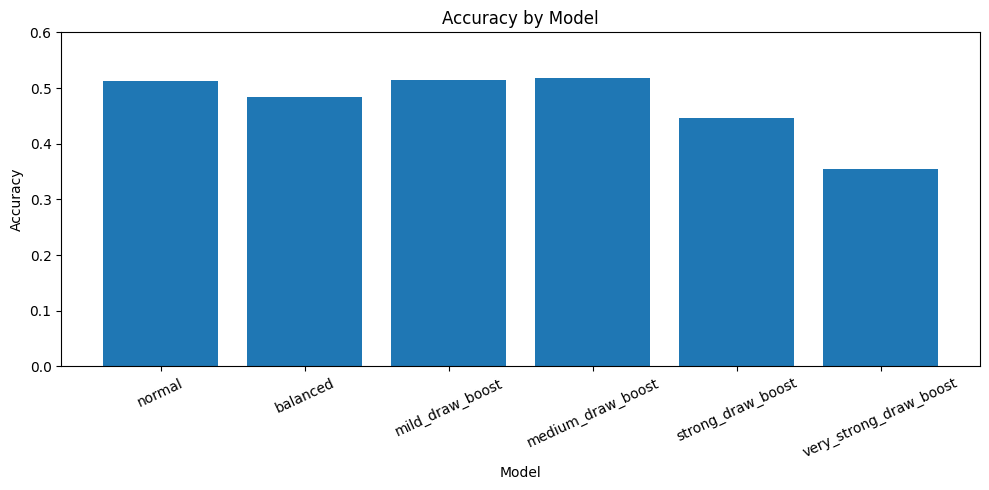

In [260]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 0.6)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

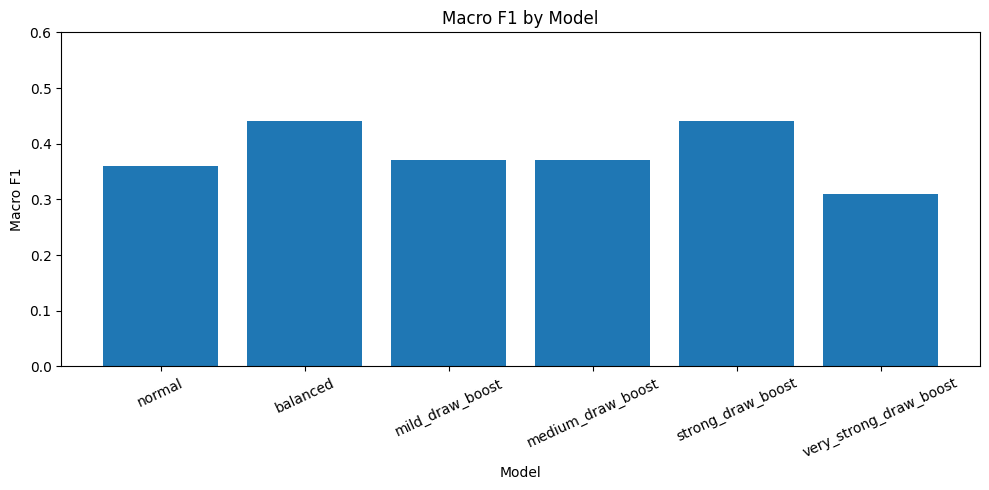

In [261]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["macro_f1"])
plt.title("Macro F1 by Model")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 0.6)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

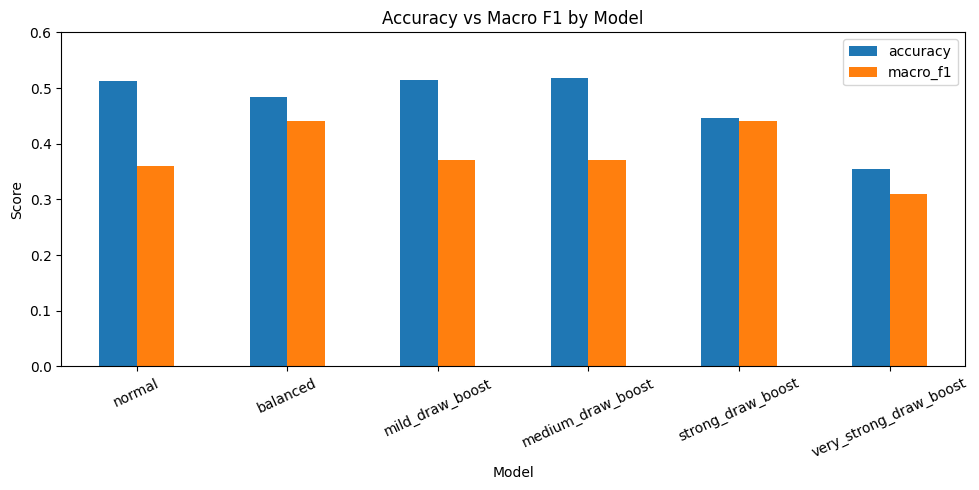

In [262]:
comparison_metrics_df = results_df[["model", "accuracy", "macro_f1"]].set_index("model")

comparison_metrics_df.plot(kind="bar", figsize=(10, 5))
plt.title("Accuracy vs Macro F1 by Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 0.6)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

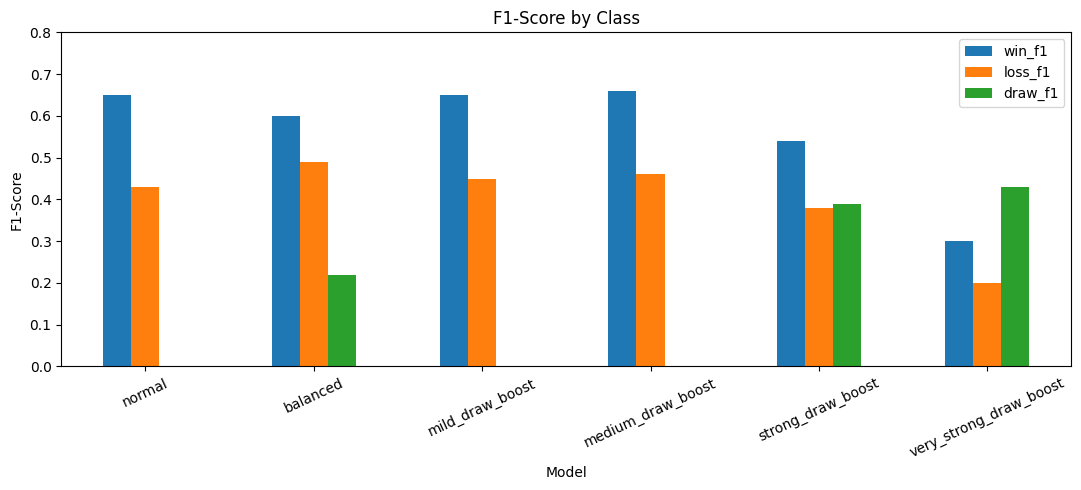

In [263]:
class_f1_df = results_df[
    ["model", "win_f1", "loss_f1", "draw_f1"]
].set_index("model")

class_f1_df.plot(kind="bar", figsize=(11, 5))
plt.title("F1-Score by Class")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 0.8)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

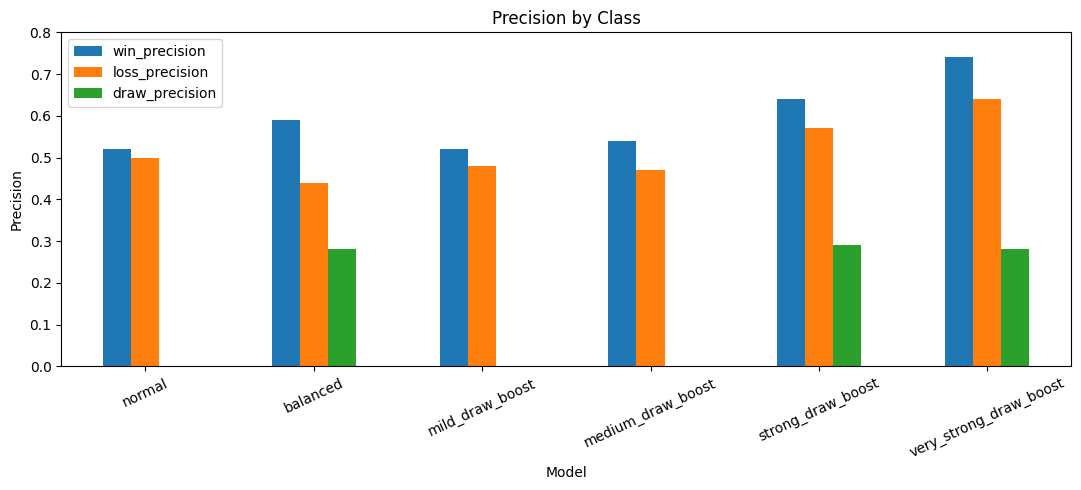

In [264]:
precision_df = results_df[
    ["model", "win_precision", "loss_precision", "draw_precision"]
].set_index("model")

precision_df.plot(kind="bar", figsize=(11, 5))
plt.title("Precision by Class")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 0.8)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

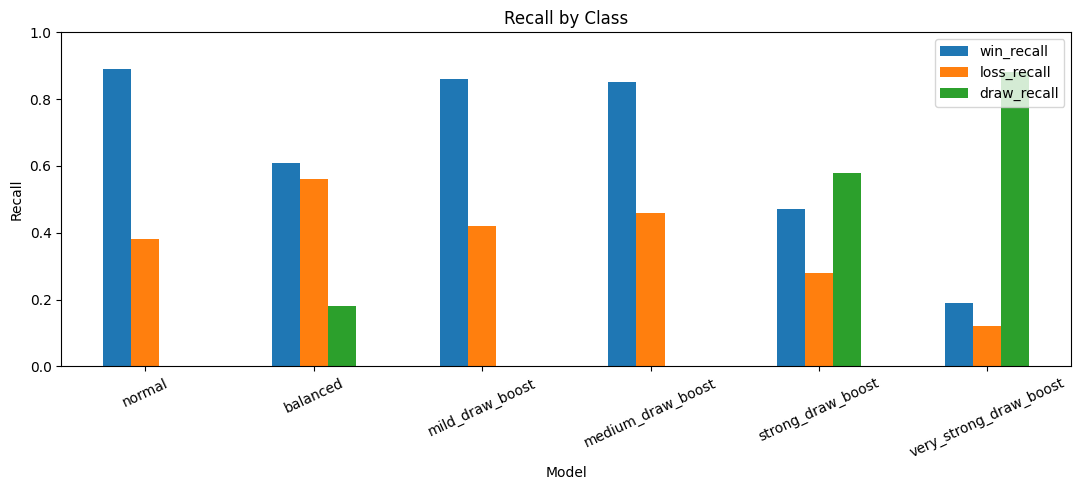

In [265]:
recall_df = results_df[
    ["model", "win_recall", "loss_recall", "draw_recall"]
].set_index("model")

recall_df.plot(kind="bar", figsize=(11, 5))
plt.title("Recall by Class")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1.0)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

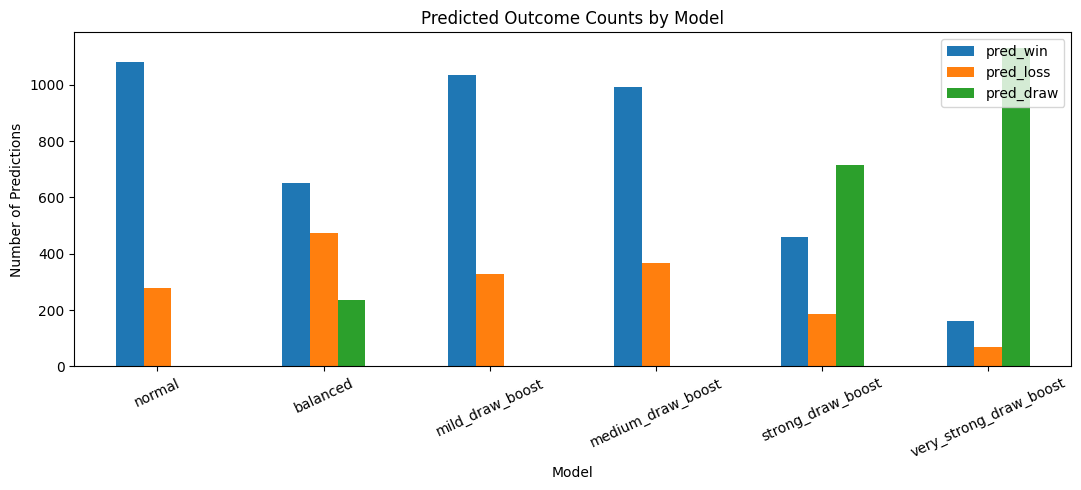

In [266]:
pred_counts_df = results_df[
    ["model", "pred_win", "pred_loss", "pred_draw"]
].set_index("model")

pred_counts_df.plot(kind="bar", figsize=(11, 5))
plt.title("Predicted Outcome Counts by Model")
plt.xlabel("Model")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

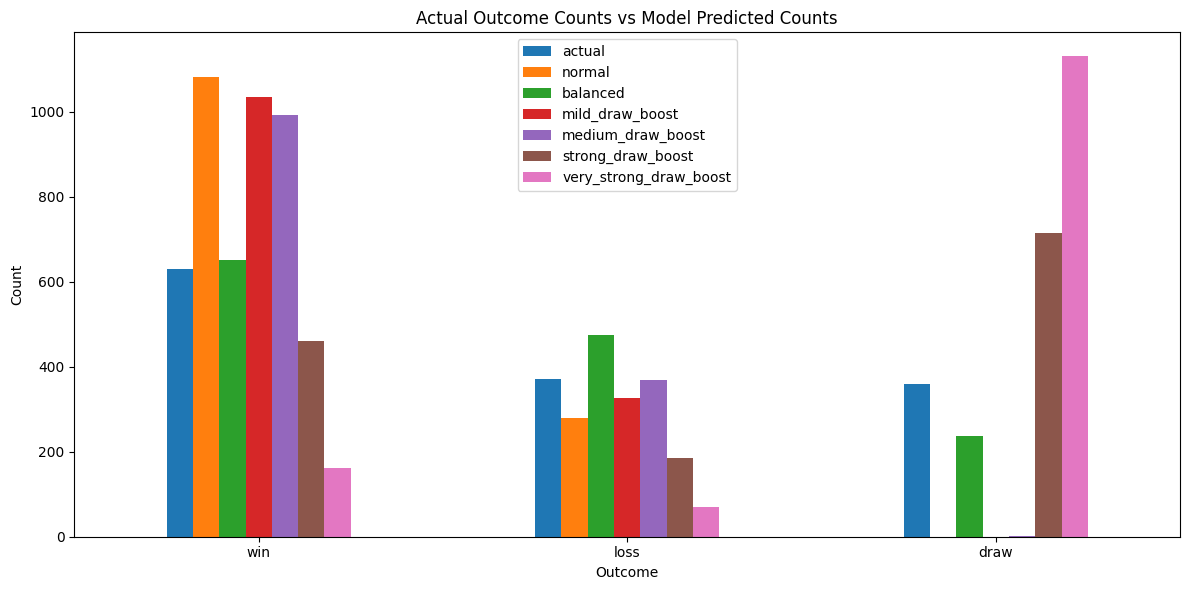

In [269]:
actual_vs_pred_df = pd.DataFrame({
    "actual": actual_counts,
    "normal": pd.Series({
        "win": 1081,
        "loss": 280,
        "draw": 0
    }),
    "balanced": pd.Series({
        "win": 650,
        "loss": 475,
        "draw": 236
    }),
    "mild_draw_boost": pd.Series({
        "win": 1034,
        "loss": 327,
        "draw": 0
    }),
    "medium_draw_boost": pd.Series({
        "win": 992,
        "loss": 368,
        "draw": 1
    }),
    "strong_draw_boost": pd.Series({
        "win": 461,
        "loss": 185,
        "draw": 715
    }),
    "very_strong_draw_boost": pd.Series({
        "win": 161,
        "loss": 70,
        "draw": 1130
    })
})
actual_vs_pred_df.plot(kind="bar", figsize=(12, 6))
plt.title("Actual Outcome Counts vs Model Predicted Counts")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

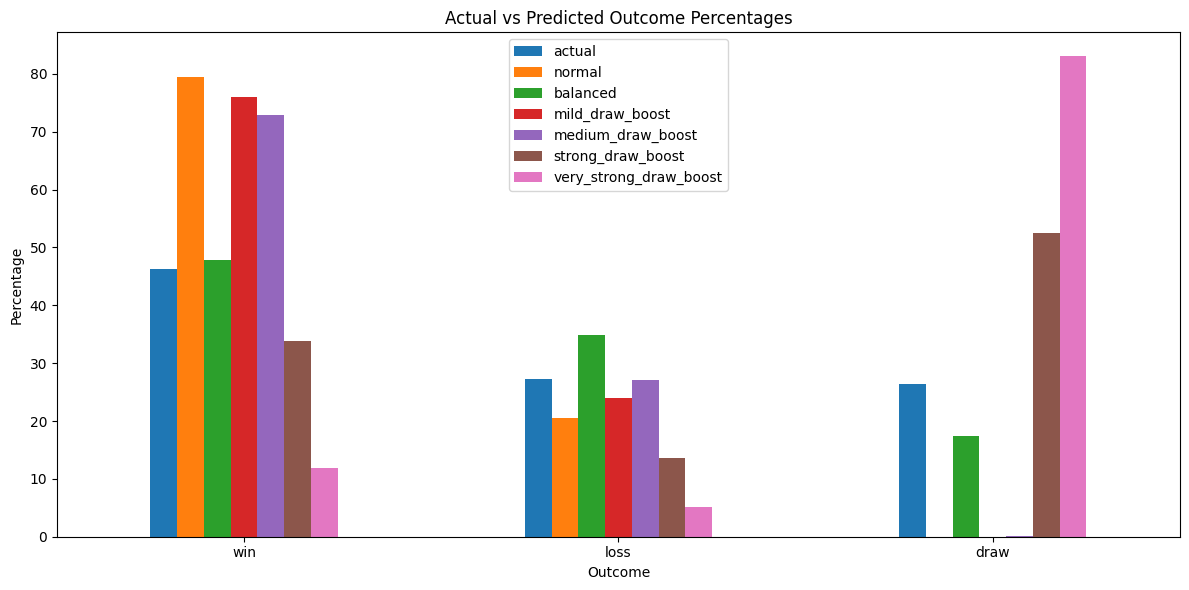

In [271]:
pred_percent_df = actual_vs_pred_df.div(actual_vs_pred_df.sum(axis=0), axis=1) * 100

pred_percent_df.plot(kind="bar", figsize=(12, 6))
plt.title("Actual vs Predicted Outcome Percentages")
plt.xlabel("Outcome")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()